# ID16A Line-Profile Processing (Example)

This notebook demonstrates the workflow for a **single** ID16A dataset (one CSV):
1. Plot the **raw** line profiles.
2. Compute and apply a **baseline correction** using specified baseline windows.
3. Plot the **averaged corrected** line profile with ±1 standard deviation.
4. Export the averaged profile + std to CSV.

- Column 0: distance in **pixels** → converted to µm using `0.100 µm/pixel`.
- Intensity columns: every other column starting from column 1.


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ==== Parameters ====
FILE_PATH = "data/ID16A/ID16A_Epon_lineprofiles_SK186_p2_n100.csv"  # <-- set this to one CSV file

PIXELS_TO_UM = 0.100      # µm per pixel for ID16A (100 nm)
SAVE_FIGS = True
FIG_DPI = 300

EPS = 1e-12  # small number to avoid division-by-zero if ever needed

In [10]:
# defaults
plt.rcParams.update({
    "font.size": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.5,
    "figure.dpi": 150
})

In [11]:
def safe_read_csv(file_path):
    """Safely read a CSV file with basic error handling."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    return pd.read_csv(file_path, header=None, low_memory=False)


def build_baseline_mask(dist_um):
    """Return a boolean mask for baseline regions with fixed windows in µm."""
    baseline_windows_um = [(0, 1.8), (6.2, 8)]
    mask = np.zeros_like(dist_um, dtype=bool)
    for lo, hi in baseline_windows_um:
        mask |= (dist_um >= lo) & (dist_um <= hi)
    return mask


def extract_profiles(df, pixels_to_um=0.100):
    """
    From a raw dataframe:
      - Convert the first column (pixels) -> distance in µm
      - Take every other column starting at col 1 as profiles
      - Multiply profiles by conversion factor to match P14 units (rad/voxel)
    Returns: dist_um (N,), profiles (N, M) in P14 units
    """
    dist_um = df.iloc[:, 0].to_numpy(dtype=float) * pixels_to_um
    profiles = df.iloc[:, 1::2].to_numpy(dtype=float)

    # --- Conversion factor (per cm → rad/voxel as in P14 units)  [see text below]---
    conversion_factor = 0.512 * 0.325 * 1e-4
    profiles = profiles * conversion_factor

    return dist_um, profiles


def baseline_correct_profiles(dist_um, profiles):
    """
    Subtract per-profile baseline mean using fixed windows:
      - 0 → 1.8 µm
      - 6.2 → 8 µm
    Returns: corrected_profiles (N, M), baseline_means (M,)
    """
    base_mask = build_baseline_mask(dist_um)
    corrected = np.empty_like(profiles)
    baseline_means = np.empty(profiles.shape[1])
    for i in range(profiles.shape[1]):
        base_mean = np.mean(profiles[base_mask, i])
        baseline_means[i] = base_mean
        corrected[:, i] = profiles[:, i] - base_mean
    return corrected, baseline_means


def compute_avg_and_std(corrected_profiles):
    """Compute mean and std across profiles (axis=1)."""
    mean_profile = np.mean(corrected_profiles, axis=1)
    std_profile  = np.std(corrected_profiles, axis=1, ddof=0)
    return mean_profile, std_profile

### Unit Conversion (ID16A → P14)

At ID16A, the holotomographic reconstruction provides values as:

$$
\omega = - \frac{2\pi}{\lambda} \, \delta
$$

in units of **cm$^{-1}$**.

To compare directly with P14 (which reports in **rad/voxel**), each line profile
is multiplied by the conversion factor:

$$
\text{factor} = 0.512 \times 0.325 \times 10^{-4}
$$

where 0.512 arrises from the the ratio of the X-ray wavelength (energies) at P14 to ID16A, and  0.325 $\times 10^{-4}$ is the pixel size at P14 in per cm units. 

This converts ID16A values into the same effective units as P14.

In [12]:
df = safe_read_csv(FILE_PATH)
dist_um, profiles = extract_profiles(df, pixels_to_um=PIXELS_TO_UM)

print(f"Loaded: {FILE_PATH}")
print(f"Distance array length: {dist_um.size}, profiles shape: {profiles.shape}")

Loaded: /Users/khans3/Desktop/Experiments/X-rays/Analysis/ID16a/beamtime_240911/CPD_Analysis/Line_Profile_Approach/SK186_p2/lineprofiles_SK185_p1_300ms_n100.csv
Distance array length: 80, profiles shape: (80, 100)


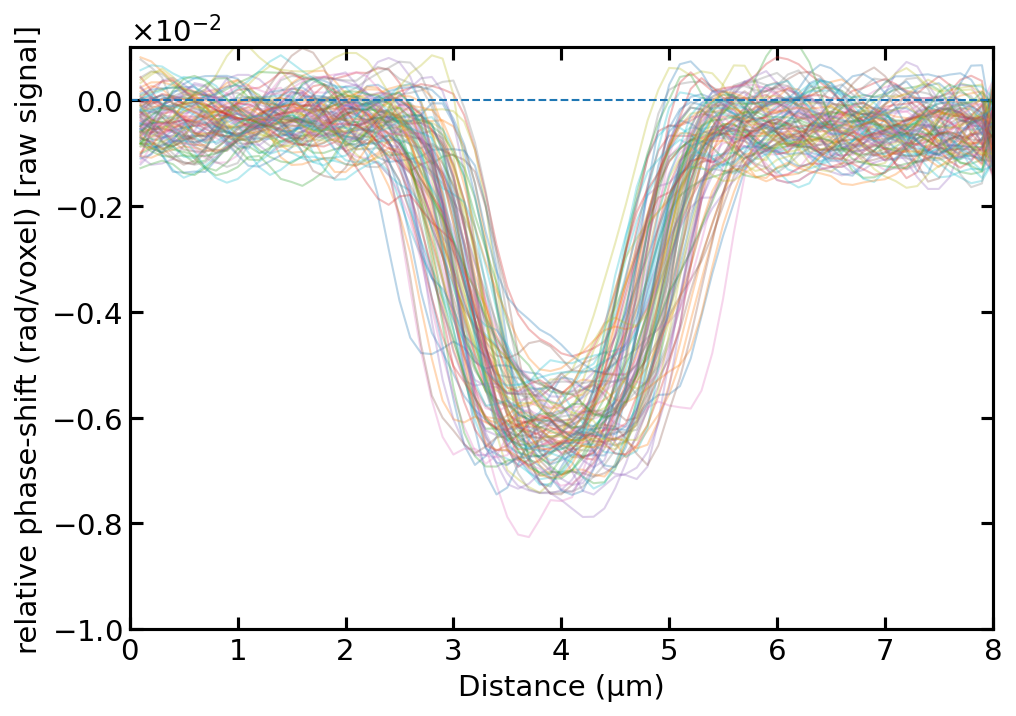

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(profiles.shape[1]):
    ax.plot(dist_um, profiles[:, i], alpha=0.3, linewidth=1)

ax.axhline(0, linestyle='--', linewidth=1)
ax.set_xlabel("Distance (µm)")
ax.set_ylabel("relative phase-shift (rad/voxel) [raw signal]")
ax.set_xlim(0, 8)
ax.set_ylim(-1e-2, 1e-3)

# Force scientific notation on y-axis if needed
fmt = ScalarFormatter(useMathText=True)
fmt.set_scientific(True)
fmt.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(fmt)

ax.tick_params(axis='both', length=6, width=1.5)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("ID16A_raw_profiles.svg", format='svg', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

In [14]:
corrected_profiles, baseline_means = baseline_correct_profiles(dist_um, profiles)
print(f"Computed baseline means for {profiles.shape[1]} profiles. "
      f"Example (first 5): {baseline_means[:5]}")

Computed baseline means for 100 profiles. Example (first 5): [-0.00035242 -0.00028053 -0.00044416 -0.00022544 -0.00036138]


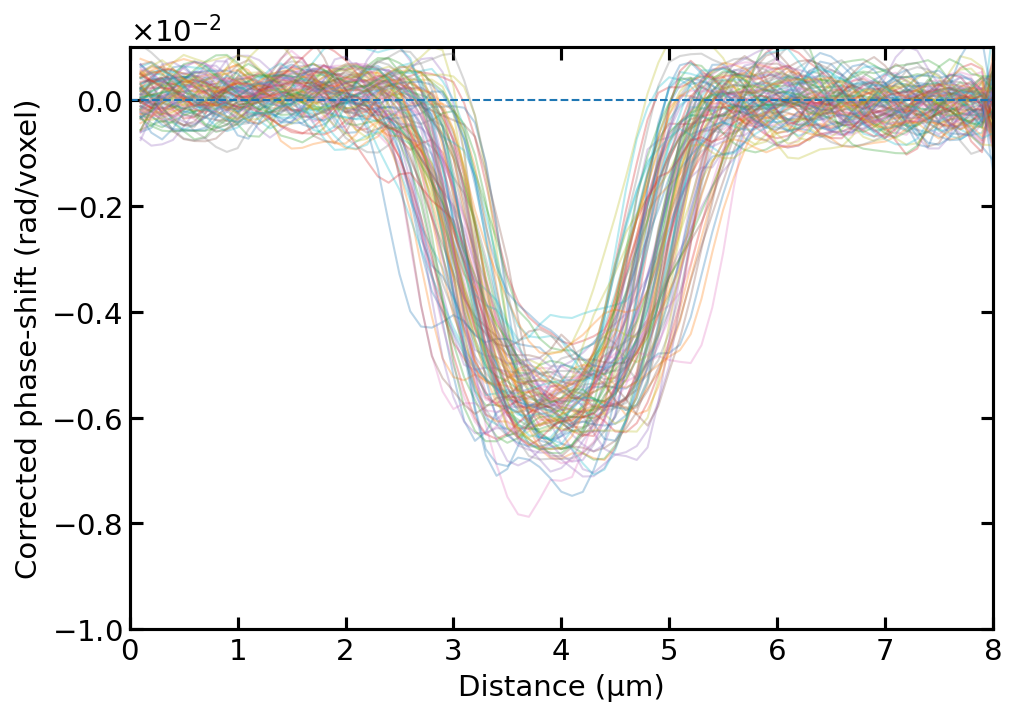

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(corrected_profiles.shape[1]):
    ax.plot(dist_um, corrected_profiles[:, i], alpha=0.3, linewidth=1)

ax.axhline(0, linestyle='--', linewidth=1)
ax.set_xlabel("Distance (µm)")
ax.set_ylabel("Corrected phase-shift (rad/voxel)")
ax.set_xlim(0, 8)
ax.set_ylim(-1e-2, 1e-3)

fmt = ScalarFormatter(useMathText=True)
fmt.set_scientific(True)
fmt.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(fmt)

ax.tick_params(axis='both', length=6, width=1.5)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("ID16A_corrected_profiles.svg", format='svg', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

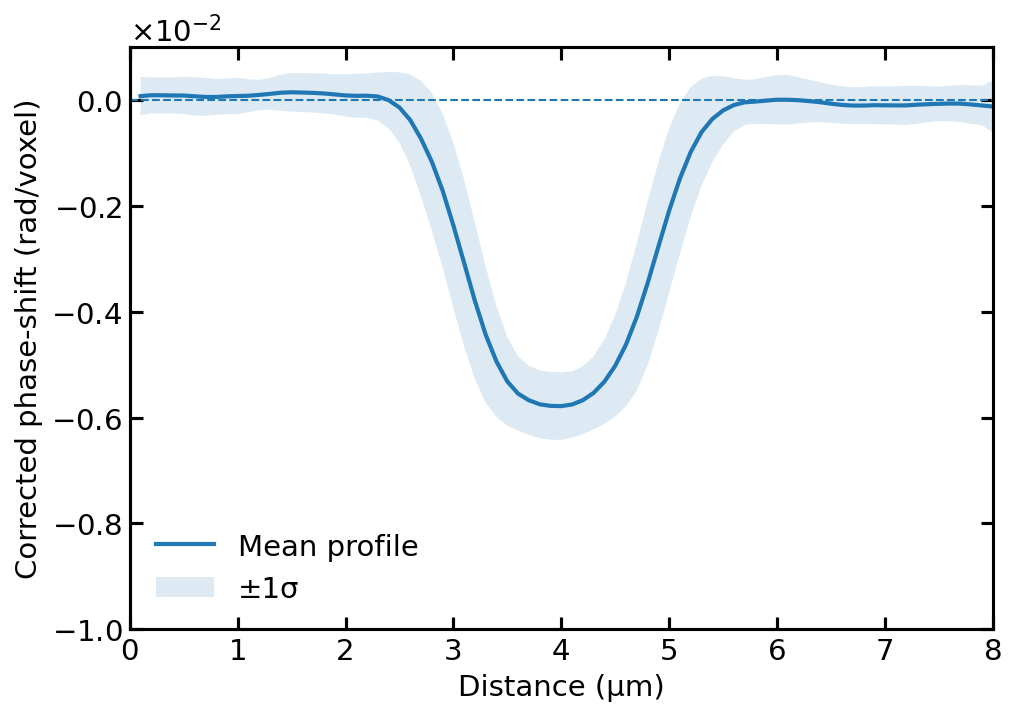

In [16]:
mean_profile, std_profile = compute_avg_and_std(corrected_profiles)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(dist_um, mean_profile, linewidth=2, label='Mean profile')
ax.fill_between(dist_um, mean_profile - std_profile, mean_profile + std_profile,
                alpha=0.15, label='±1σ')

ax.axhline(0, linestyle='--', linewidth=1)
ax.set_xlabel("Distance (µm)")
ax.set_ylabel("Corrected phase-shift (rad/voxel)")
ax.set_xlim(0, 8)
ax.set_ylim(-1e-2, 1e-3)

fmt = ScalarFormatter(useMathText=True)
fmt.set_scientific(True)
fmt.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(fmt)

ax.legend(frameon=False)
ax.tick_params(axis='both', length=6, width=1.5)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("ID16A_corrected_mean_with_std.svg", format='svg', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

In [ ]:
export_df = pd.DataFrame({
    'Distance (µm)': dist_um,
    'Mean Corrected Profile': mean_profile,
    'Standard Deviation': std_profile
})
out_csv = "ID16A_averaged_corrected_profile.csv"
export_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")